# Predicción de churn — split temporal forward

**Setup:**
- **Test**: bloque de las **últimas `TEST_WINDOW` campañas** del dataset (`campana_rank_obs ∈ [last − TEST_WINDOW + 1, last]`).
- **Train**: todas las observaciones con `campana_rank_obs ≤ (primer_test_rank − GAP)`.
- **GAP = 7 campañas** entre el fin del train y el inicio del test: el target de la última fila de train mira 6 campañas hacia adelante; con gap = 7 esas 6 campañas terminan justo antes del test → cero overlap entre el target de train y el periodo del test.

**Por qué un bloque y no una sola campaña**: cada campaña individual del final del dataset tiene entre ~20 y ~200 filas y un churn rate que oscila entre 16% y 48%. Evaluar sobre una sola campaña deja N≈50, IC95% del AUC ≈ ±0.10 — número no interpretable. Un bloque de 12 campañas da N≈1000–1500 y permite además medir estabilidad por campaña.

**Diferencia con el notebook 03 (GroupKFold):**

| Aspecto | NB 03 — GroupKFold | NB 04 — Split temporal forward |
|---|---|---|
| Pregunta | ¿Generaliza a vendedoras *nuevas*? | ¿Funciona en producción sobre campañas futuras? |
| ¿Misma vendedora en train y test? | No (controlado) | Sí (esperado: refleja prod real) |
| AUC esperado | Honesto para vendedora nueva | Optimista en ~5pp por reconocimiento de identidad (`STATUS.md` punto 1) |

Modelo: HGB balanceado (ganador del NB 03).

In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve,
    confusion_matrix, classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
TABLE = f'`{PROJECT}.{DATASET}.training_churn_v3`'
RANDOM_STATE = 42

bq = bigquery.Client(project=PROJECT)
df = bq.query(f'SELECT * FROM {TABLE}').to_dataframe()
print(f'shape: {df.shape}  vendedoras: {df["id_vendedor"].nunique():,}  '
      f'rango campana_rank_obs: {df["campana_rank_obs"].min()} → {df["campana_rank_obs"].max()}')

shape: (21911, 51)  vendedoras: 3,155  rango campana_rank_obs: 4 → 150


## Split temporal

In [7]:
TEST_WINDOW = 12   # cantidad de campañas más recientes que van al test
GAP = 7            # campañas de separación entre fin de train e inicio de test

last_rank = int(df['campana_rank_obs'].max())
test_min_rank = last_rank - TEST_WINDOW + 1
test_max_rank = last_rank
train_max_rank = test_min_rank - GAP

train_mask = df['campana_rank_obs'] <= train_max_rank
test_mask  = df['campana_rank_obs'].between(test_min_rank, test_max_rank)

df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

# Mapear ranks a id_campana_obs para el log.
def rank_to_campana(r):
    s = df.loc[df['campana_rank_obs'] == r, 'id_campana_obs']
    return int(s.iloc[0]) if len(s) else None

print(f'Última campaña con target en dataset (rank): {last_rank}')
print(f'Test  → campana_rank_obs ∈ [{test_min_rank}, {test_max_rank}]   '
      f'(id_campana_obs ∈ [{rank_to_campana(test_min_rank)}, {rank_to_campana(test_max_rank)}])')
print(f'Train → campana_rank_obs ≤ {train_max_rank}                     '
      f'(≤ id_campana_obs {rank_to_campana(train_max_rank)})')
print()
print(f'Train: {len(df_train):>6,} filas · {df_train["id_vendedor"].nunique():>5,} vendedoras · '
      f'{df_train["id_campana_obs"].nunique():>3} campañas · churn rate {df_train["churn"].mean():.4f}')
print(f'Test : {len(df_test):>6,} filas · {df_test["id_vendedor"].nunique():>5,} vendedoras · '
      f'{df_test["id_campana_obs"].nunique():>3} campañas · churn rate {df_test["churn"].mean():.4f}')
overlap = len(set(df_train["id_vendedor"]) & set(df_test["id_vendedor"]))
print(f'Vendedoras presentes en train Y test: {overlap:,} '
      f'({overlap / df_test["id_vendedor"].nunique() * 100:.1f}% del test) — esperado en split temporal')

Última campaña con target en dataset (rank): 150
Test  → campana_rank_obs ∈ [139, 150]   (id_campana_obs ∈ [25111, 26104])
Train → campana_rank_obs ≤ 132                     (≤ id_campana_obs 25104)

Train: 19,909 filas · 3,020 vendedoras · 125 campañas · churn rate 0.2740
Test :  1,143 filas ·   500 vendedoras ·  12 campañas · churn rate 0.3561
Vendedoras presentes en train Y test: 393 (78.6% del test) — esperado en split temporal


## Features y pipeline

In [8]:
EXCLUDE = {
    'id_vendedor', 'id_campana_obs', 'campana_rank_obs',
    'fecha_inicio_campana', 'fecha_ingreso',
    'id_coordinadora', 'ccodubigeo', 'distrito',
    'churn',
}
CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']
feature_cols = [c for c in df.columns if c not in EXCLUDE]
numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]

for d in (df_train, df_test):
    for c in CATEGORICAL:
        d[c] = d[c].astype('string').fillna('NA')

X_train, y_train = df_train[feature_cols], df_train['churn'].astype(int).values
X_test,  y_test  = df_test[feature_cols],  df_test['churn'].astype(int).values

prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CATEGORICAL),
])

model = Pipeline([
    ('prep', prep),
    ('clf', HistGradientBoostingClassifier(
        class_weight='balanced',
        max_iter=400,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    )),
])

model.fit(X_train, y_train)
print('Modelo entrenado.')

Modelo entrenado.


## Métricas en test (penúltima campaña)

In [9]:
proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, proba)
ap  = average_precision_score(y_test, proba)

print(f'ROC-AUC          : {auc:.4f}')
print(f'PR-AUC (AP)      : {ap:.4f}  (prevalencia test {y_test.mean():.4f})')
print(f'F1@0.5           : {f1_score(y_test, pred):.3f}')
print(f'Recall@0.5       : {recall_score(y_test, pred):.3f}')
print(f'Precision@0.5    : {precision_score(y_test, pred, zero_division=0):.3f}')
print()
print('Matriz de confusión @ thr=0.5')
cm = confusion_matrix(y_test, pred)
print(pd.DataFrame(cm,
    index=['real: no-churn', 'real: churn'],
    columns=['pred: no-churn', 'pred: churn']))
print()
print(classification_report(y_test, pred, target_names=['no-churn', 'churn'], digits=3))

ROC-AUC          : 0.7294
PR-AUC (AP)      : 0.5755  (prevalencia test 0.3561)
F1@0.5           : 0.590
Recall@0.5       : 0.794
Precision@0.5    : 0.469

Matriz de confusión @ thr=0.5
                pred: no-churn  pred: churn
real: no-churn             371          365
real: churn                 84          323

              precision    recall  f1-score   support

    no-churn      0.815     0.504     0.623       736
       churn      0.469     0.794     0.590       407

    accuracy                          0.607      1143
   macro avg      0.642     0.649     0.606      1143
weighted avg      0.692     0.607     0.611      1143



## Estabilidad temporal: AUC por campaña dentro del test

Si el AUC del bloque agregado es bueno pero las campañas individuales oscilan mucho, el modelo no es confiable campaña a campaña. Si todas las campañas del test están en un rango estrecho, el resultado es robusto.

In [10]:
df_test_eval = df_test.copy()
df_test_eval['proba'] = proba

per_campana = []
for r, g in df_test_eval.groupby('campana_rank_obs'):
    yt = g['churn'].astype(int).values
    pp = g['proba'].values
    n_pos = int(yt.sum())
    if n_pos == 0 or n_pos == len(yt):
        # ROC-AUC indefinido si la clase es constante en la campaña.
        per_campana.append({
            'rank': int(r), 'id_campana': int(g['id_campana_obs'].iloc[0]),
            'n': len(yt), 'n_churn': n_pos, 'churn_rate': float(yt.mean()),
            'AUC': np.nan, 'AP': average_precision_score(yt, pp) if n_pos else np.nan,
        })
        continue
    per_campana.append({
        'rank': int(r), 'id_campana': int(g['id_campana_obs'].iloc[0]),
        'n': len(yt), 'n_churn': n_pos, 'churn_rate': float(yt.mean()),
        'AUC': roc_auc_score(yt, pp),
        'AP': average_precision_score(yt, pp),
    })

per_campana = pd.DataFrame(per_campana).sort_values('rank').reset_index(drop=True)
print(per_campana.to_string(index=False))
print()
print(f"AUC por campaña — media {per_campana['AUC'].mean():.3f}, "
      f"std {per_campana['AUC'].std():.3f}, "
      f"min {per_campana['AUC'].min():.3f}, max {per_campana['AUC'].max():.3f}")
print(f"AUC del bloque agregado    : {auc:.3f}  (este es el número a reportar)")

 rank  id_campana   n  n_churn  churn_rate      AUC       AP
  139       25111 146       53    0.363014 0.666667 0.532199
  140       25112  19        4    0.210526 0.650000 0.371429
  141       25113 167       68    0.407186 0.818627 0.779567
  142       25114  45        7    0.155556 0.729323 0.342052
  143       25115 194       93    0.479381 0.761099 0.739284
  144       25116  51        8    0.156863 0.546512 0.178682
  145       25117  53        9    0.169811 0.626263 0.235240
  146       25118 114       45    0.394737 0.780032 0.718444
  147       26101  61       16    0.262295 0.759722 0.513305
  148       26102 120       32    0.266667 0.687145 0.458906
  149       26103  51       20    0.392157 0.620968 0.469908
  150       26104 122       52    0.426230 0.780357 0.691099

AUC por campaña — media 0.702, std 0.082, min 0.547, max 0.819
AUC del bloque agregado    : 0.729  (este es el número a reportar)


## Curva PR + puntos operativos

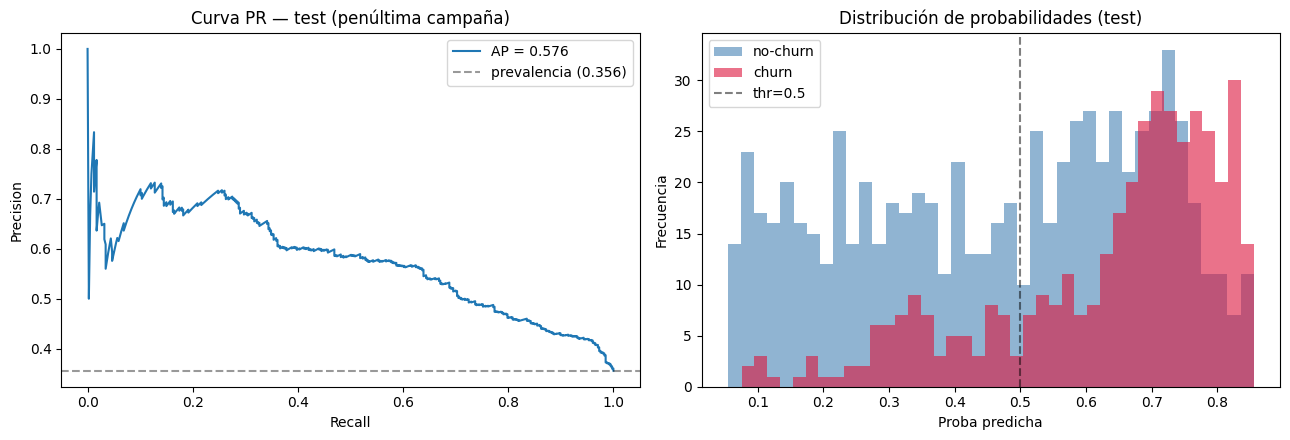

,objetivo recall,threshold,recall,precision,F1,alertas (% test)
0,0.95,0.288007,0.950860,0.419740,0.582393,0.806649
1,0.90,0.338302,0.901720,0.427739,0.580237,0.750656
2,0.85,0.417315,0.850123,0.450521,0.588936,0.671916
3,0.80,0.480567,0.800983,0.462411,0.586331,0.616798
4,0.70,0.593250,0.700246,0.516304,0.594369,0.482940
5,0.60,0.657353,0.601966,0.565820,0.583333,0.378828
6,0.50,0.695439,0.501229,0.587896,0.541114,0.303587


In [11]:
prec_c, rec_c, thr_c = precision_recall_curve(y_test, proba)
f1_c = 2 * prec_c * rec_c / np.clip(prec_c + rec_c, 1e-12, None)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(rec_c, prec_c, label=f'AP = {ap:.3f}')
axes[0].axhline(y_test.mean(), ls='--', color='k', alpha=0.4,
                label=f'prevalencia ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva PR — test (penúltima campaña)'); axes[0].legend()

axes[1].hist(proba[y_test == 0], bins=40, alpha=0.6, label='no-churn', color='steelblue')
axes[1].hist(proba[y_test == 1], bins=40, alpha=0.6, label='churn', color='crimson')
axes[1].axvline(0.5, ls='--', color='k', alpha=0.5, label='thr=0.5')
axes[1].set_xlabel('Proba predicha'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de probabilidades (test)'); axes[1].legend()
plt.tight_layout(); plt.show()

rows = []
for target_recall in [0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.50]:
    ok = rec_c[:-1] >= target_recall
    if not ok.any(): continue
    idx = np.where(ok)[0][-1]
    rows.append({
        'objetivo recall': target_recall,
        'threshold': float(thr_c[idx]),
        'recall': float(rec_c[idx]),
        'precision': float(prec_c[idx]),
        'F1': float(f1_c[idx]),
        'alertas (% test)': float((proba >= thr_c[idx]).mean()),
    })
pd.DataFrame(rows)